In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBRegressor

In [6]:
# Load dataset
df = pd.read_csv("garbage_4000_rows.csv")

# Convert date
df["date"] = pd.to_datetime(df["date"])

# Extract date features
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["weekday"] = df["date"].dt.weekday

# Encode categorical column
le = LabelEncoder()
df["land_use"] = le.fit_transform(df["land_use"])

# Features
X = df[[
    'lat','lon',
    'pop_density',
    'dist_market_m',
    'land_use',
    'road_density',
    'shops_count',
    'rainfall_mm',
    'holiday',
    'hours_since_pickup',
    'prev_day_qty',
    'avg_7day_qty',
    'day','month','weekday'
]]

# Target
y = df["garbage_qty_kg"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2 Score:", round(r2,3))

MAE: 8.75
RMSE: 11.23
R2 Score: 0.979


               feature  importance
11        avg_7day_qty    0.558905
10        prev_day_qty    0.407102
6          shops_count    0.009701
3        dist_market_m    0.003946
8              holiday    0.003207
2          pop_density    0.003116
5         road_density    0.002006
12                 day    0.001878
0                  lat    0.001730
1                  lon    0.001559
4             land_use    0.001489
13               month    0.001473
7          rainfall_mm    0.001317
9   hours_since_pickup    0.001288
14             weekday    0.001284


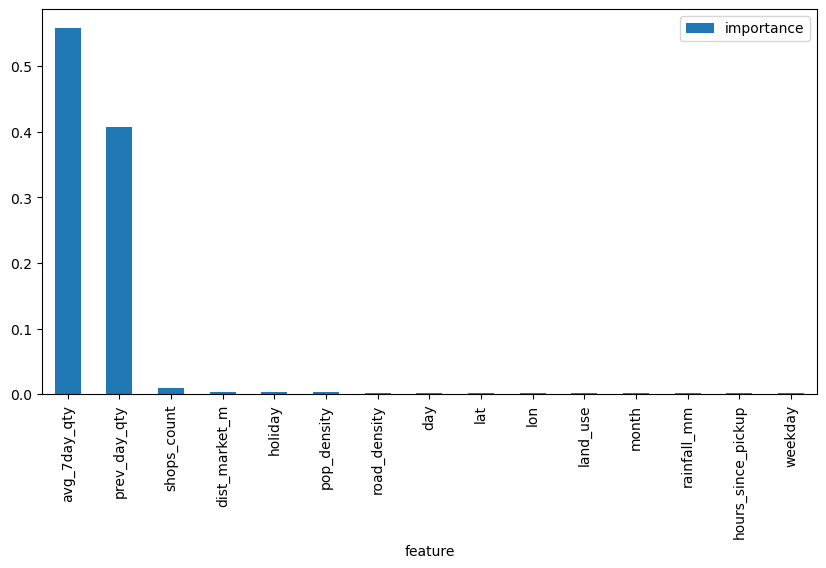

In [7]:
import matplotlib.pyplot as plt

imp = model.feature_importances_
cols = X.columns

feat = pd.DataFrame({
    "feature": cols,
    "importance": imp
}).sort_values("importance", ascending=False)

print(feat)

feat.plot(kind="bar", x="feature", y="importance", figsize=(10,5))
plt.show()

In [8]:
import joblib
joblib.dump(model, "garbage_model.pkl")

['garbage_model.pkl']

In [9]:
new_data = [[
28.36,79.43,12000,300,1,7.2,25,0,0,8,150,145,10,4,2
]]

prediction = model.predict(new_data)
print("Predicted Garbage:", prediction[0], "kg")

Predicted Garbage: 157.50935 kg


In [ ]:
df.columns

Index(['point_id', 'date', 'lat', 'lon', 'pop_density', 'dist_market_m',
       'land_use', 'road_density', 'shops_count', 'rainfall_mm', 'holiday',
       'hours_since_pickup', 'prev_day_qty', 'avg_7day_qty', 'garbage_qty_kg',
       'day', 'month', 'weekday'],
      dtype='object')